In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import SGD
from torch.utils.data.dataloader import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
from tqdm import tqdm

(32, 32, 3)


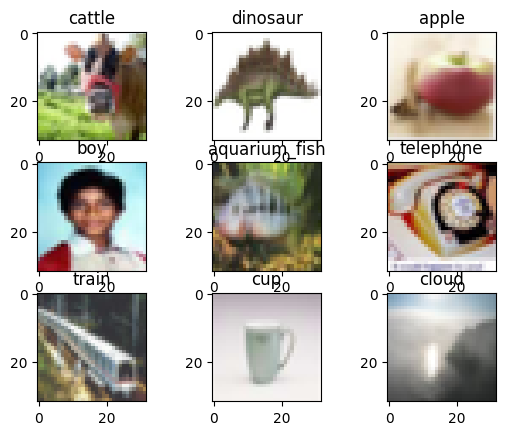

In [4]:

# CIFAR-100 데이터셋 정의
train_data = datasets.CIFAR100(
    './data/',
    train=True,
    download=True,
    transform=transforms.Compose([
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomCrop(32, padding=4),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

test_data = datasets.CIFAR100(
    root="./data/",
    train=False,
    download=True,
    transform=transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
    ]))

# 데이터 확인
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(train_data.data[i])
    plt.title(train_data.classes[train_data.targets[i]])

print(train_data.data[0].shape)
plt.show()

In [5]:
class BasicBlock(nn.Module):
    def __init__(self, in_channels, out_channels, hidden_dim):
        super(BasicBlock, self).__init__()

        # Conv -> BN -> ReLU
        self.conv1 = nn.Conv2d(in_channels, hidden_dim, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(hidden_dim) # BN

        self.conv2 = nn.Conv2d(hidden_dim, out_channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels) # BN

        self.relu = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)

        x = self.pool(x)
        return x

In [6]:
class CNN(nn.Module):
    def __init__(self, num_classes): # 클래스 개수
        super(CNN, self).__init__()

        # CNN 블럭 정의, 레이어 4개
        self.block1 = BasicBlock(in_channels=3, out_channels=32, hidden_dim=16)
        self.block2 = BasicBlock(in_channels=32, out_channels=128, hidden_dim=64)
        self.block3 = BasicBlock(in_channels=128, out_channels=256, hidden_dim=128)
        self.block4 = BasicBlock(in_channels=256, out_channels=512, hidden_dim=256)

        # classification을 위한 FC 정의
        self.fc1 = nn.Linear(in_features=512 * 2 * 2, out_features=1024)
        self.fc2 = nn.Linear(in_features=1024, out_features=256)
        self.fc3 = nn.Linear(in_features=256, out_features=num_classes)

        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.block4(x) # 추가된 블록

        x = torch.flatten(x, start_dim=1) # 평탄화

        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        x = self.relu(x)
        x = self.fc3(x)

        return x

In [7]:
# 데이터로더 정의
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)
test_loader = DataLoader(test_data, batch_size=256, shuffle=False)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"device 정보: {device}")

# CNN 모델 정의 CIFAR-100이므로 클래스 100개
model = CNN(num_classes=100)
model.to(device)

device 정보: cuda


CNN(
  (block1): BasicBlock(
    (conv1): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block2): BasicBlock(
    (conv1): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU()
    (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (block3): BasicBlock(
    (conv1): Conv2d(12

In [8]:
# Learning rate
lr = 1e-2 # 학습률 0.01

# Optimizer: SGD
optim = SGD(model.parameters(), lr=lr, momentum=0.9) # momentum 추가

# Train loop
for epoch in range(20):
    for data, label in tqdm(train_loader): # read data
        optim.zero_grad() # Initialization

        preds = model(data.to(device)) # prediction

        # Loss Function
        loss = nn.CrossEntropyLoss()(preds, label.to(device))
        loss.backward()
        optim.step()

    print(f"epoch{epoch+1} loss:{loss.item()}")

# 모델 저장
torch.save(model.state_dict(), "CIFAR100_SGD.pth")

100%|██████████| 196/196 [00:24<00:00,  8.04it/s]


epoch1 loss:3.6576857566833496


100%|██████████| 196/196 [00:23<00:00,  8.40it/s]


epoch2 loss:3.33301043510437


100%|██████████| 196/196 [00:23<00:00,  8.22it/s]


...

epoch18 loss:1.0074586868286133


100%|██████████| 196/196 [00:22<00:00,  8.76it/s]


epoch19 loss:0.9015835523605347


100%|██████████| 196/196 [00:21<00:00,  8.98it/s]

epoch20 loss:1.0249160528182983


In [9]:
model.load_state_dict(torch.load("CIFAR100_SGD.pth", map_location=device))

num_corr = 0

with torch.no_grad():
    for data, label in tqdm(test_loader):
        output = model(data.to(device))
        preds = output.data.max(1)[1]
        corr = preds.eq(label.to(device).data).sum().item()
        num_corr += corr

    print(f"Accuracy:{num_corr/len(test_data)}")

100%|██████████| 40/40 [00:02<00:00, 14.14it/s]

Accuracy:0.592
